# Overfitting and Underfitting

Overfitting and underfitting are two fundamental problems in machine learning.

A good machine learning model should learn the underlying pattern in the training data and generalize well to unseen data.

There are three important situations:

1. Underfitting
2. Good Fit
3. Overfitting

The main goal is to find a model that is complex enough to capture the underlying pattern but not so complex that it learns noise from the training data.

## 1. What is Model Fitting?

Model fitting is the process of finding a mathematical function that describes the relationship between input features and the target variable.

Suppose we have:

$$
y = f(x) + \epsilon
$$

where:

- $x$ = input feature
- $y$ = target
- $f(x)$ = underlying relationship
- $\epsilon$ = random noise

A machine learning model tries to learn an approximation:

$$
\hat{f}(x) \approx f(x)
$$

The quality of the model depends on how well it performs on both:

- Training data
- Unseen data

A model that performs well only on training data is not necessarily a good model.

## 2. Underfitting

Underfitting occurs when a model is too simple to capture the important patterns in the data.

The model has not learned enough from the training data.

Typical characteristics:

- High training error
- High validation/test error
- Model is too simple
- Important patterns are missed
- Usually associated with high bias

Example:

If the true relationship between $x$ and $y$ is nonlinear but we use a simple linear model, the model may underfit the data.

### Symptoms of Underfitting

A model is likely underfitting when:

$$
Training\ Error \gg 0
$$

and

$$
Validation\ Error \gg 0
$$

Both training and validation performance are poor.

The model cannot even explain the training data properly.

Common causes:

- Model is too simple
- Too few features
- Excessive regularization
- Insufficient training
- Poor feature engineering

## 3. Good Fit

A good-fitting model learns the important structure in the training data and generalizes well to unseen data.

Typical characteristics:

- Low training error
- Low validation/test error
- Small generalization gap
- Appropriate model complexity

The model captures the underlying relationship without learning unnecessary noise.

## 4. Overfitting

Overfitting occurs when a model becomes too complex and starts learning noise and random fluctuations in the training data.

The model performs extremely well on training data but performs poorly on unseen data.

Typical characteristics:

- Very low training error
- High validation/test error
- Large generalization gap
- Model is too complex
- Usually associated with high variance

An overfitted model has essentially memorized parts of the training data instead of learning a general pattern.

### Symptoms of Overfitting

An overfitted model often has:

$$
Training\ Error \approx 0
$$

but

$$
Validation\ Error \gg Training\ Error
$$

The difference between training and validation performance is called the generalization gap.

$$
Generalization\ Gap
=
Validation\ Error - Training\ Error
$$

A large generalization gap is an important warning sign of overfitting.

## 5. Underfitting vs Good Fit vs Overfitting

| Situation | Model Complexity | Training Error | Validation Error | Main Problem |
|------------|------------------|----------------|------------------|--------------|
| Underfitting | Too Low | High | High | Model is too simple |
| Good Fit | Appropriate | Low | Low | Good generalization |
| Overfitting | Too High | Very Low | High | Model learns noise |

The objective is not to minimize training error alone.

Instead, we want to minimize the error on unseen data.

## 6. Visual Intuition

Consider a dataset generated from a nonlinear relationship.

We can fit models with different levels of complexity:

- Degree 1 polynomial → likely underfitting
- Degree 3 polynomial → potentially good fit
- Degree 15 polynomial → potentially overfitting

As model complexity increases:

$$
Underfitting
\rightarrow
Good\ Fit
\rightarrow
Overfitting
$$

This demonstrates the importance of choosing an appropriate model complexity.

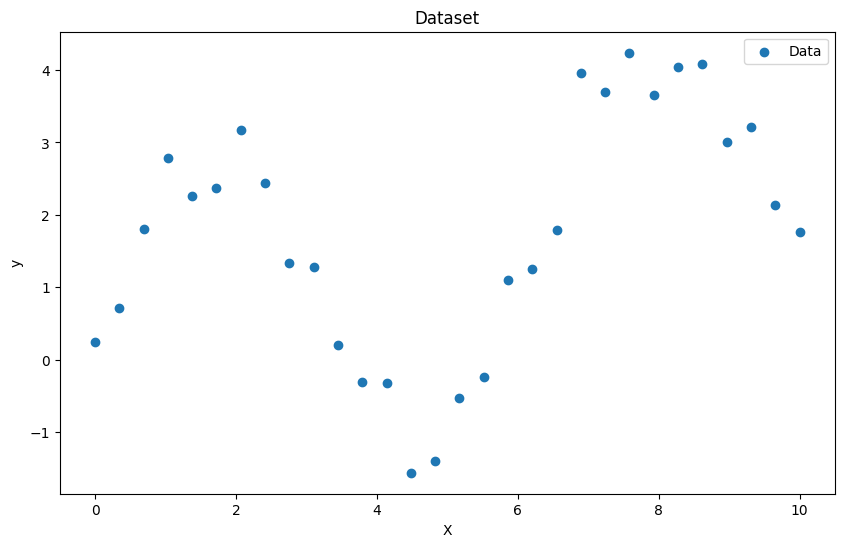

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(0, 10, 30)

y = (
    2 * np.sin(X)
    + 0.3 * X
    + np.random.normal(0, 0.5, len(X))
)

plt.figure(figsize=(10, 6))

plt.scatter(X, y, label="Data")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset")

plt.legend()
plt.show()

## 7. Polynomial Regression and Model Complexity

Polynomial regression allows us to control model complexity using the polynomial degree.

A polynomial model can be written as:

$$
\hat{y}
=
\beta_0
+
\beta_1x
+
\beta_2x^2
+
\cdots
+
\beta_dx^d
$$

where $d$ is the polynomial degree.

A larger degree allows the model to represent more complex relationships.

However, increasing complexity does not always improve generalization.

Too little complexity can cause underfitting.

Too much complexity can cause overfitting.

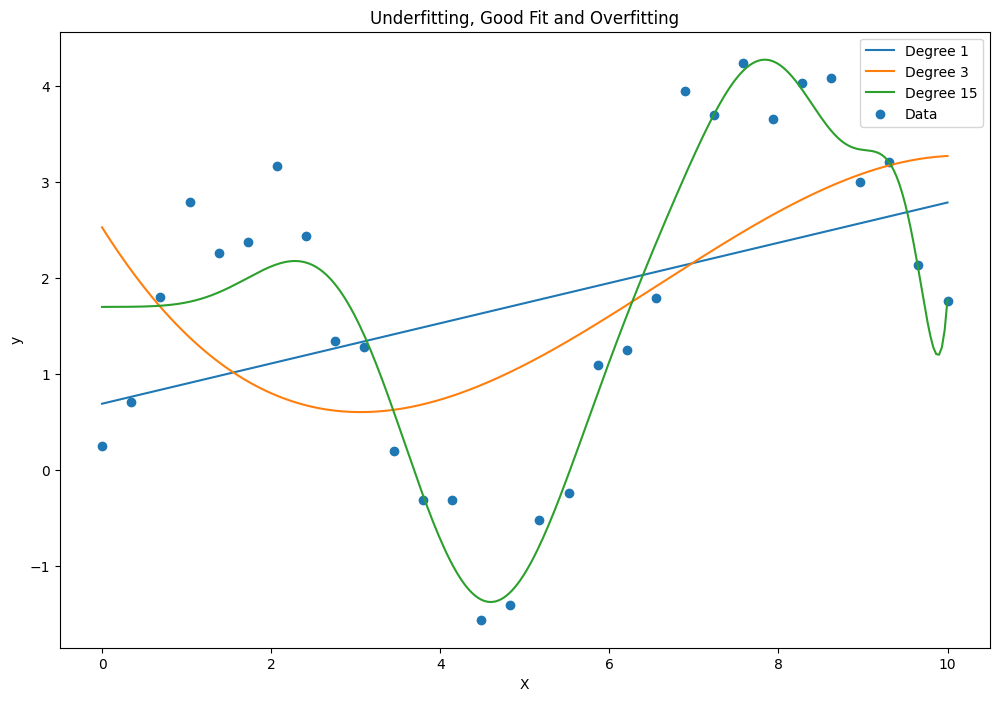

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

degrees = [1, 3, 15]

plt.figure(figsize=(12, 8))

X_plot = np.linspace(0, 10, 300)

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X.reshape(-1, 1), y)

    y_plot = model.predict(X_plot.reshape(-1, 1))

    plt.plot(
        X_plot,
        y_plot,
        label=f"Degree {degree}"
    )

plt.scatter(X, y, label="Data")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Underfitting, Good Fit and Overfitting")

plt.legend()
plt.show()

## 8. Interpreting the Polynomial Curves

### Degree 1

The model is very simple.

It cannot capture the nonlinear structure of the data.

This is an example of underfitting.

### Degree 3

The model is more flexible and can capture the main nonlinear pattern.

This may provide a good balance between complexity and generalization.

### Degree 15

The model is extremely flexible.

It may follow individual fluctuations in the training data instead of learning the underlying pattern.

This is an example of overfitting.

The important lesson is:

> More complex does not always mean better.

## 9. Training Error and Validation Error

One of the most useful ways to detect overfitting and underfitting is to compare training and validation performance.

For each model complexity:

1. Train the model on the training data.
2. Calculate training error.
3. Calculate validation error.
4. Compare the two errors.

A typical pattern is:

$$
\text{Low Complexity}
\rightarrow
\text{High Bias}
$$

and

$$
\text{High Complexity}
\rightarrow
\text{High Variance}
$$

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(
    X.reshape(-1, 1),
    y,
    test_size=0.3,
    random_state=42
)

degrees = range(1, 16)

train_errors = []
val_errors = []

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_errors.append(
        mean_squared_error(y_train, train_pred)
    )

    val_errors.append(
        mean_squared_error(y_val, val_pred)
    )

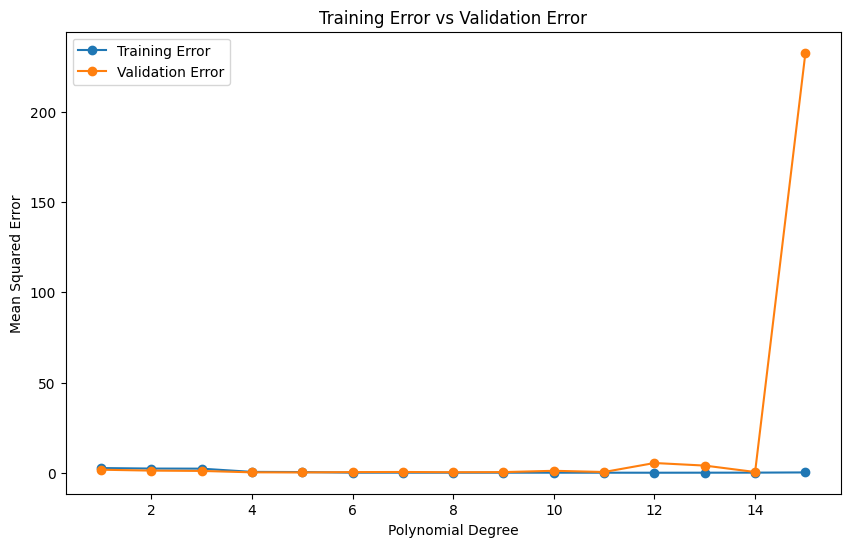

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    degrees,
    val_errors,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training Error vs Validation Error")

plt.legend()
plt.show()

## 10. Understanding the Error Curve

The typical pattern is:

### Low Complexity

The model is too simple.

$$
Training\ Error \uparrow
$$

$$
Validation\ Error \uparrow
$$

This indicates underfitting.

### Appropriate Complexity

The model captures the important structure.

$$
Training\ Error \downarrow
$$

$$
Validation\ Error \downarrow
$$

This is the desired region.

### High Complexity

Training error continues to decrease, but validation error begins to increase.

$$
Training\ Error \downarrow
$$

while

$$
Validation\ Error \uparrow
$$

This is a classic sign of overfitting.

Therefore, model selection should focus on validation performance rather than training performance alone.

## 11. Generalization

Generalization is the ability of a machine learning model to perform well on unseen data.

A model should learn patterns that are useful beyond the training dataset.

We can think of the goal as:

$$
Good\ Training\ Performance
+
Good\ Unseen\ Data\ Performance
$$

A model that performs well only on the training data has poor generalization.

This is why validation and test datasets are important.

## 12. Generalization Gap

The generalization gap measures the difference between training and validation performance.

For error-based metrics:

$$
Generalization\ Gap
=
Validation\ Error
-
Training\ Error
$$

A small gap generally indicates that the model behaves similarly on training and unseen validation data.

A large positive gap can indicate overfitting.

However, the gap should always be interpreted together with the absolute error.

For example:

- High training error + high validation error → likely underfitting
- Low training error + low validation error → good fit
- Very low training error + high validation error → likely overfitting

## 13. Connection with Bias and Variance

Overfitting and underfitting are closely related to the bias-variance tradeoff.

### Underfitting

Usually corresponds to:

$$
High\ Bias
$$

The model makes strong assumptions and is not flexible enough.

### Overfitting

Usually corresponds to:

$$
High\ Variance
$$

The model is highly sensitive to the particular training dataset.

### Good Fit

The model attempts to find a suitable balance between bias and variance.

Therefore:

$$
Underfitting
\approx
High\ Bias
$$

$$
Overfitting
\approx
High\ Variance
$$

## 14. Causes of Underfitting

Common causes include:

1. Model is too simple
2. Important features are missing
3. Excessive regularization
4. Insufficient training
5. Poor feature representation
6. Incorrect assumptions about the data

Example:

Using a linear model for a strongly nonlinear problem can cause underfitting.

## 15. How to Fix Underfitting

Possible solutions:

### 1. Increase Model Complexity

Use a more flexible model.

Examples:

- Higher-degree polynomial
- Decision tree with greater depth
- More flexible neural network

### 2. Add Better Features

Feature engineering can provide the model with more useful information.

### 3. Reduce Regularization

If regularization is too strong, the model may become unnecessarily constrained.

### 4. Train Longer

For iterative models such as neural networks, insufficient training can lead to underfitting.

The goal is to increase the model's ability to learn meaningful patterns.

## 16. Causes of Overfitting

Common causes include:

1. Model is too complex
2. Too little training data
3. Too many features
4. Noisy training data
5. Excessive training
6. Insufficient regularization
7. Data leakage

A highly flexible model can memorize noise and random patterns in the training dataset.

## 17. How to Fix Overfitting

Common techniques include:

### 1. Use More Training Data

More representative data can help the model learn general patterns.

### 2. Reduce Model Complexity

Examples:

- Lower polynomial degree
- Smaller decision tree
- Fewer parameters

### 3. Regularization

Regularization penalizes overly complex models.

Examples:

- L1 regularization
- L2 regularization

### 4. Cross-Validation

Cross-validation provides a more reliable estimate of generalization performance.

### 5. Feature Selection

Remove irrelevant or noisy features.

### 6. Early Stopping

Useful for iterative models such as neural networks.

### 7. Data Augmentation

Particularly useful in areas such as computer vision and deep learning.

## 18. Regularization

Regularization adds a penalty for model complexity.

For example, L2 regularization modifies the objective function:

$$
Loss_{regularized}
=
Loss
+
\lambda \sum_{j=1}^{d}\beta_j^2
$$

where:

- $\lambda$ controls the regularization strength
- $\beta_j$ are model parameters

A larger $\lambda$ produces stronger regularization.

Too much regularization can cause underfitting.

Too little regularization can allow overfitting.

Therefore, regularization strength should usually be selected using validation data or cross-validation.

## 19. Learning Curves

A learning curve shows model performance as the amount of training data increases.

It can help diagnose:

- Underfitting
- Overfitting
- Whether additional training data may help

We typically plot:

$$
Training\ Error
$$

and

$$
Validation\ Error
$$

against the number of training examples.

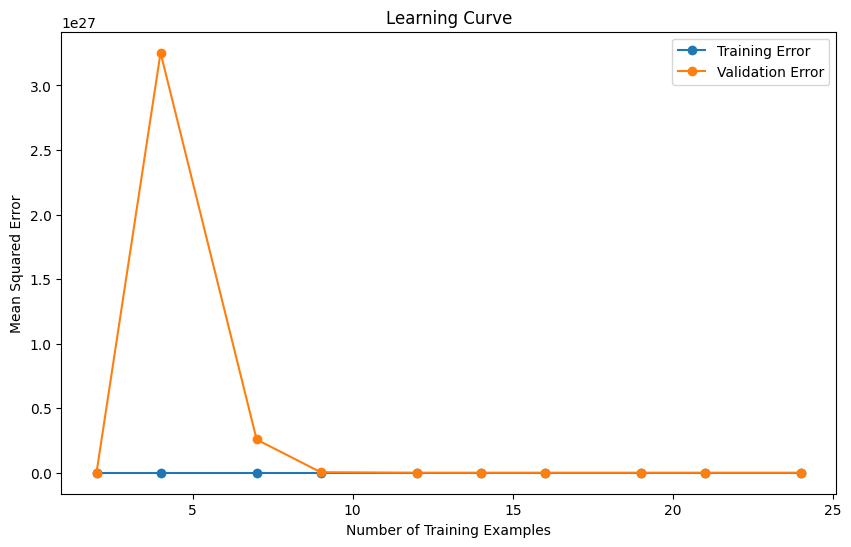

In [5]:
from sklearn.model_selection import learning_curve

model = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X.reshape(-1, 1),
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_error = -train_scores.mean(axis=1)
val_error = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_error,
    marker="o",
    label="Training Error"
)

plt.plot(
    train_sizes,
    val_error,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Number of Training Examples")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve")

plt.legend()
plt.show()

## 20. Model Complexity Curve

A model complexity curve compares model performance against model complexity.

For example:

$$
Complexity
=
Polynomial\ Degree
$$

As complexity increases:

- Training error usually decreases
- Validation error initially decreases
- Validation error eventually increases

The minimum validation error often occurs near the useful complexity level.

Conceptually:

$$
Underfitting
\rightarrow
Optimal\ Complexity
\rightarrow
Overfitting

## 21. Practical Strategy for Detecting Overfitting and Underfitting

When training a machine learning model, compare training and validation performance.

### Case 1: Both Perform Poorly

$$
Training\ Performance \approx Poor
$$

$$
Validation\ Performance \approx Poor
$$

Likely problem:

**Underfitting**

### Case 2: Training Good, Validation Poor

$$
Training\ Performance \approx Excellent
$$

$$
Validation\ Performance \approx Poor
$$

Likely problem:

**Overfitting**

### Case 3: Both Perform Well

$$
Training\ Performance \approx Good
$$

$$
Validation\ Performance \approx Good
$$

Likely situation:

**Good Generalization**

Always remember that the exact interpretation depends on the metric and the problem.

## 22. Overfitting in Classification

Overfitting is not limited to regression.

In classification, we can observe:

- Training accuracy
- Validation accuracy
- Training loss
- Validation loss

For example:

| Model | Training Accuracy | Validation Accuracy |
|------|-------------------|---------------------|
| Simple | 72% | 70% |
| Moderate | 91% | 89% |
| Very Complex | 99% | 78% |

The very complex model has the highest training accuracy but performs much worse on validation data.

This is a typical overfitting pattern.

## 23. Real-World Example

Suppose we build a model to predict house prices.

### Underfitting

The model uses only:

- Number of bedrooms

It may miss important factors such as:

- Location
- Area
- Age
- Distance from city center
- Number of bathrooms

The model may be too simple.

### Good Fit

The model uses meaningful features and learns the major relationships.

### Overfitting

The model becomes extremely complex and learns unusual patterns specific to the training houses.

It may perform exceptionally well on historical houses but poorly on new houses.

The goal is to build a model that generalizes to houses it has never seen before.

## 24. Summary

### Underfitting

- Model is too simple
- High bias
- Training error is high
- Validation error is high
- Increase model complexity
- Improve features
- Reduce excessive regularization

### Good Fit

- Appropriate complexity
- Training error is low
- Validation error is low
- Small generalization gap
- Good generalization

### Overfitting

- Model is too complex
- High variance
- Training error is very low
- Validation error is significantly higher
- Reduce model complexity
- Use regularization
- Use more data
- Use cross-validation
- Perform feature selection

The key principle is:

$$
\boxed{
Choose\ the\ model\ that\ generalizes\ well
}
$$

# Final Mental Model

Think of model complexity as a spectrum:

$$
Too\ Simple
\quad\longrightarrow\quad
Appropriate
\quad\longrightarrow\quad
Too\ Complex
$$

This corresponds to:

$$
Underfitting
\quad\longrightarrow\quad
Good\ Fit
\quad\longrightarrow\quad
Overfitting
$$

And approximately:

$$
High\ Bias
\quad\longrightarrow\quad
Balanced
\quad\longrightarrow\quad
High\ Variance
$$

The most important lesson is:

**Do not choose a model because it performs best on the training data. Choose a model based on how well it generalizes to unseen data.**

# Key Takeaways

1. Underfitting means the model is too simple to learn the important pattern.

2. Overfitting means the model is too complex and learns noise from the training data.

3. Training performance alone is not enough to evaluate a model.

4. Validation data helps estimate how well the model generalizes.

5. Increasing model complexity generally decreases training error.

6. Increasing complexity can eventually increase validation error.

7. Regularization helps control model complexity.

8. Cross-validation helps select models and hyperparameters more reliably.

9. Learning curves and validation curves are useful diagnostic tools.

10. The ultimate goal of machine learning is **generalization**, not memorization.